# Dataset
This notebook provides an example of the data utilised to generate a forecast using Aardvark Weather. We explore a single timeslice containing all the observations required to generate a forecast. This sample data is the output of the loader `WeatherDatasetE2E` in `../aardvark/loaders.py`.

In [4]:
import io
import numpy as np
import pickle
import torch

In [5]:
import matplotlib
from matplotlib import pyplot as plt

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'


## Data
Open a sample of data required to produce a forecast.

In [ ]:
class CPU_Unpickler(pickle.Unpickler):
    """define a custom unpickler to load tensors onto CPU"""
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        return super().find_class(module, name)

with open('../data/sample_data_final.pkl', 'rb') as fp:
    data = CPU_Unpickler(fp).load()

Multiple different datasets are utilised as input to create a forecast, each with multiple channels including observations and metadata. Example channels for each of these are plotted below. The plot_channel variable in each cell can be adjusted to visualise different channels. 

In [7]:
# Set up longitude and latitude for plotting
lon = np.linspace(0,359,360)
lat = np.linspace(90,-90,181)

lon_1p5 = np.linspace(0,359,240)
lat_1p5 = np.linspace(90,-90,121)

## Satellite
First visualise the satellite data from HIRS, AMSU-A, AMSU-B, IASI and ASCAT

### HIRS — High-resolution Infrared Radiation Sounder (26 channels)

| Ch | Band | Physical measurement |
|---|---|---|
| 1–12 | Longwave CO₂ (~15 μm) | Temperature profiling from upper troposphere to stratosphere; each channel peaks at a different pressure level |
| 13 | Longwave window (~11.1 μm) | Surface / cloud-top temperature |
| 14–19 | Shortwave CO₂ (~4.3 μm) | Mid-troposphere temperature profiling |
| 20 | Visible (~0.69 μm) | Cloud detection / surface albedo |
| 21–26 | Shortwave window + water vapour | Near-surface temperature and column water vapour |

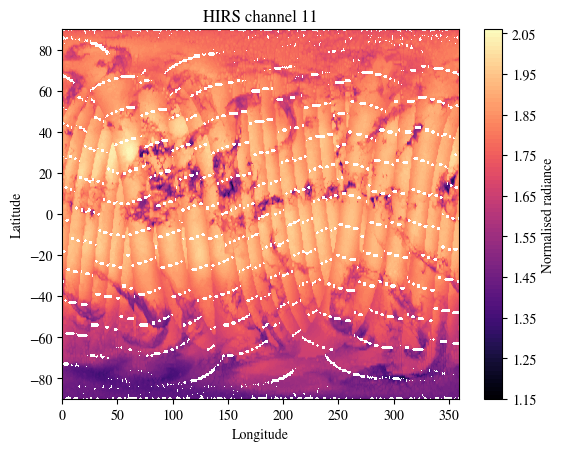

In [8]:
fig = plt.figure()
plot_channel = 11
p = plt.contourf(
    lon,
    lat,
    data["assimilation"]["hirs_current"][0,...,plot_channel].cpu().T, 
    levels=100,
    cmap="magma")
cbar = fig.colorbar(p)
cbar.set_label('Normalised radiance') 
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"HIRS channel {plot_channel}")
plt.show()

### AMSU-A — Advanced Microwave Sounding Unit-A (13 channels)

| Ch | Frequency | Physical measurement |
|---|---|---|
| 1–2 | 23.8 / 31.4 GHz (window) | Surface emissivity, cloud liquid water, precipitation |
| 3–13 | 50–60 GHz (O₂ absorption band) | Atmospheric temperature profiling from surface (~850 hPa) to upper stratosphere (~1 hPa); deeper into atmosphere with increasing channel number |

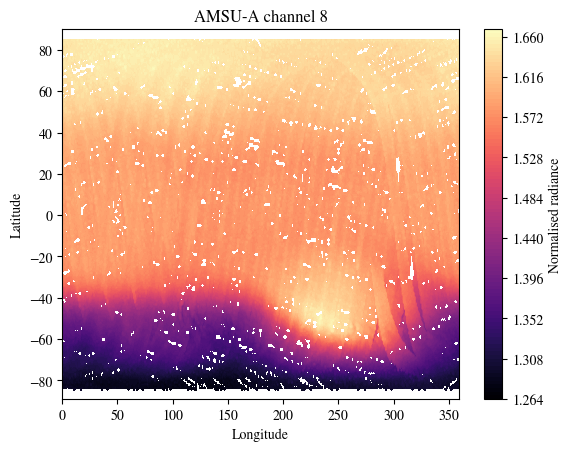

In [9]:
fig = plt.figure()
plot_channel = 8
p = plt.contourf(
    lon, 
    lat[:-1],
    data["assimilation"]["amsua_current"][0,...,plot_channel].cpu(), 
    levels=100,
    cmap="magma")
cbar = fig.colorbar(p)
cbar.set_label('Normalised radiance') 
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"AMSU-A channel {plot_channel}")
plt.show()

### AMSU-B / MHS — Microwave Humidity Sounder (12 channels)

| Ch | Frequency | Physical measurement |
|---|---|---|
| 1–2 | 89 / 150 GHz (window) | Precipitation, cloud ice water, surface emissivity |
| 3–12 | 183.31 ± 1/3/7 GHz (water vapour) | Tropospheric humidity profiling at multiple levels; channels closer to the 183 GHz line peak higher in the atmosphere |

> Note: 12 channels = 6 channels × 2 satellites (e.g. MetOp-A and MetOp-B) composited into a single daily field.

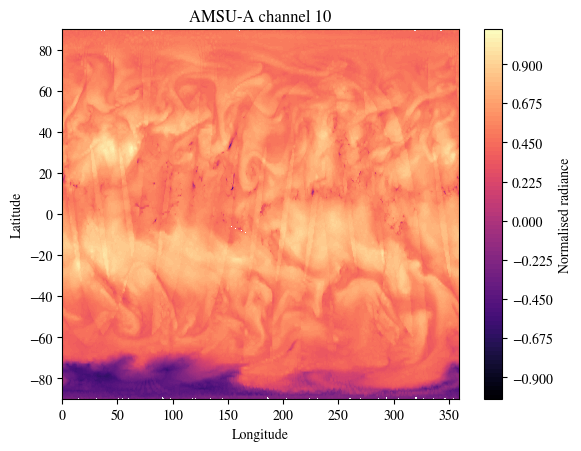

In [10]:
fig = plt.figure()
plot_channel = 10
p = plt.contourf(
    lon,
    lat,
    data["assimilation"]["amsub_current"][0,...,plot_channel].T.cpu(), 
    levels=100,
    cmap="magma")
cbar = fig.colorbar(p)
cbar.set_label('Normalised radiance') 
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"AMSU-A channel {plot_channel}")
plt.show()

### IASI — Infrared Atmospheric Sounding Interferometer (52 channels)

IASI covers 645–2760 cm⁻¹ with ~8,461 spectral channels at 0.5 cm⁻¹ resolution. The 52 channels here are **selected / principal-component compressed** channels used for NWP assimilation:

| Spectral region | Coverage |
|---|---|
| Longwave CO₂ band (645–800 cm⁻¹) | Temperature profiling, surface to stratosphere |
| Atmospheric window (800–1200 cm⁻¹) | Surface temperature, ozone (O₃) column |
| Water vapour band (1200–2000 cm⁻¹) | Humidity profiling throughout troposphere |
| Shortwave CO₂ / N₂O (2200–2400 cm⁻¹) | Upper-troposphere temperature, trace gases |

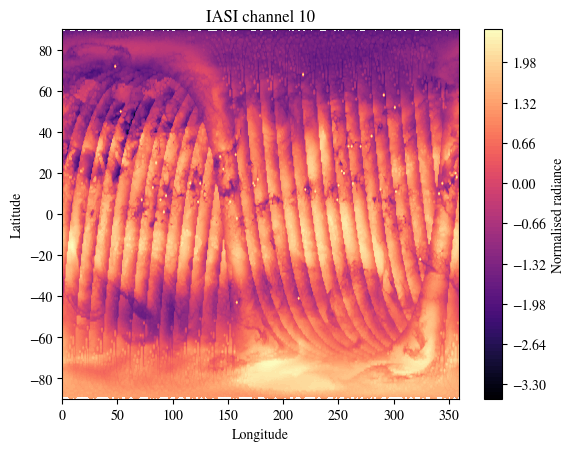

In [11]:
fig = plt.figure()
plot_channel = 10
p = plt.contourf(
    lon,
    lat,
    data["assimilation"]["iasi_current"][0,...,plot_channel].T.cpu(), 
    levels=100,
    cmap="magma")
cbar = fig.colorbar(p)
cbar.set_label('Normalised radiance') 
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"IASI channel {plot_channel}")
plt.show()

### ASCAT — Advanced Scatterometer (17 channels)

ASCAT uses C-band radar (5.255 GHz) to measure ocean surface backscatter from three antenna beams (fore, mid, aft) at both vertical and horizontal polarisation. The 17 channels encode:

| Ch | Content |
|---|---|
| 1–6 | Backscatter coefficient (σ₀) from 3 beams × 2 polarisations |
| 7–12 | Incidence angle for each beam measurement |
| 13–17 | Quality flags, noise estimate, and wind retrieval confidence |

Retrieved product: **10 m wind speed and direction** over the open ocean.

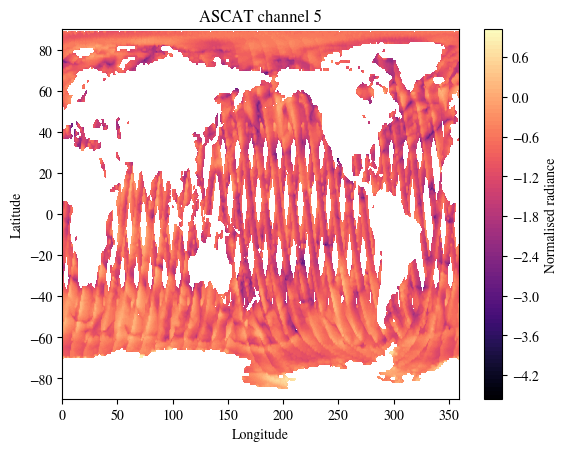

In [12]:
fig = plt.figure()
plot_channel = 5
p = plt.contourf(
    lon,
    lat,
    data["assimilation"]["ascat_current"][0,...,plot_channel].T.cpu(), 
    levels=100,
    cmap="magma")
cbar = fig.colorbar(p)
cbar.set_label('Normalised radiance') 
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"ASCAT channel {plot_channel}")
plt.show()

## SYNOPS
We next visualise the SYNOPS data from land stations, marine platforms and radiosonde profiles

### HadISD — Land Surface Synoptic Stations (5 variables, ~8,000–8,700 stations each)

| Index | Variable | Description |
|---|---|---|
| 0 | **tas** | 2 m air temperature (°C) — 8,719 stations |
| 1 | **tds** | 2 m dew-point temperature (°C) — 8,617 stations; combined with tas gives relative humidity |
| 2 | **psl** | Mean sea-level pressure (hPa) — 8,016 stations; fewer because inland elevated stations are excluded |
| 3 | **u** | 10 m eastward wind component (m/s) — 8,721 stations |
| 4 | **v** | 10 m northward wind component (m/s) — 8,721 stations |

Each variable is stored as a separate sparse list because quality control filters differ per variable, resulting in different station counts. Coordinates are (lon, lat) normalised by /360.

/var/folders/px/747r5b694x947qk1vdh9b3th0000gp/T/ipykernel_61300/1559489095.py:6: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4483.)
  c = data["assimilation"]["y_context_hadisd_current"][plot_channel][0].T.cpu(),


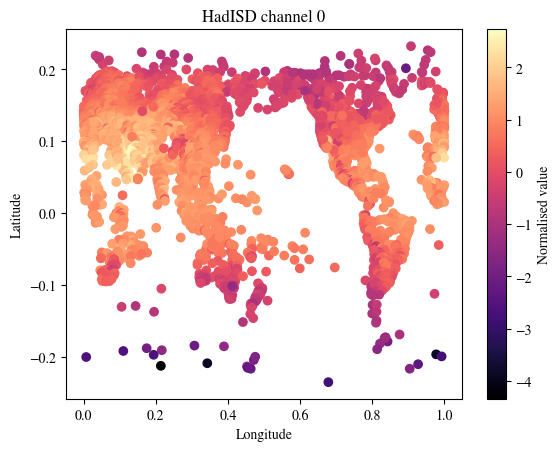

In [13]:
fig = plt.figure()
plot_channel = 0
p = plt.scatter(
    data["assimilation"]["x_context_hadisd_current"][plot_channel][0,0,:].cpu(),
    data["assimilation"]["x_context_hadisd_current"][plot_channel][0,1,:].cpu(),
    c = data["assimilation"]["y_context_hadisd_current"][plot_channel][0].T.cpu(), 
    cmap="magma")
cbar = fig.colorbar(p)
cbar.set_label('Normalised value') 
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"HadISD channel {plot_channel}")
plt.show()

### ICOADS — International Comprehensive Ocean-Atmosphere Dataset (5 channels, 12,000 reports)

Marine observations from voluntary observing ships, moored buoys, and drifting buoys, zero-padded to a fixed 12,000 reports per time step.

| Ch | Variable | Description |
|---|---|---|
| 0 | **SST** | Sea surface temperature (°C) |
| 1 | **AT** | 2 m air temperature (°C) |
| 2 | **SLP** | Sea-level pressure (hPa) |
| 3 | **u** | 10 m eastward wind component (m/s) |
| 4 | **v** | 10 m northward wind component (m/s) |

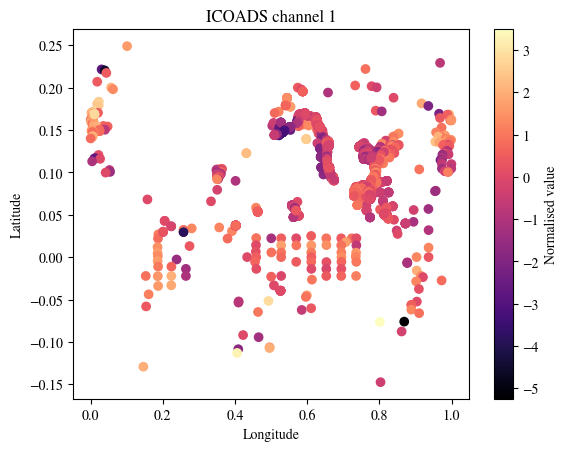

In [14]:
plot_channel = 1
fig = plt.figure()
p = plt.scatter(
    data["assimilation"]["icoads_x_current"][0][0,:].cpu(),
    data["assimilation"]["icoads_x_current"][1][0,:].cpu(),
    c = data["assimilation"]["icoads_current"][0,plot_channel,:].T.cpu(), 
    cmap="magma")
cbar = fig.colorbar(p)
cbar.set_label('Normalised value') 
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"ICOADS channel {plot_channel}")
plt.show()

### IGRA — Integrated Global Radiosonde Archive (24 channels, 1,375 stations)

Twice-daily balloon soundings providing the only **direct vertical profile** observations in the system. The 24 channels are 4 variables measured at 6 standard pressure levels:

| Pressure level | Channels (T, q, u, v) |
|---|---|
| 850 hPa (~1,500 m) | 0, 1, 2, 3 |
| 700 hPa (~3,000 m) | 4, 5, 6, 7 |
| 500 hPa (~5,500 m) | 8, 9, 10, 11 |
| 300 hPa (~9,000 m) | 12, 13, 14, 15 |
| 200 hPa (~12,000 m) | 16, 17, 18, 19 |
| 100 hPa (~16,000 m) | 20, 21, 22, 23 |

Variables at each level: **T** = temperature (K), **q** = specific humidity (kg/kg), **u** = eastward wind (m/s), **v** = northward wind (m/s).

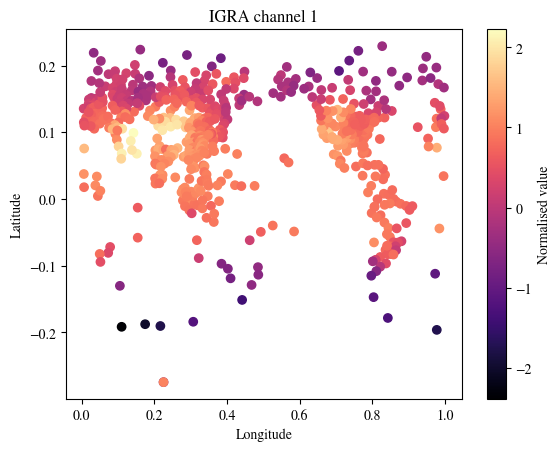

In [15]:
plot_channel = 1
fig = plt.figure()
p = plt.scatter(
    data["assimilation"]["igra_x_current"][0][0,:].cpu(),
    data["assimilation"]["igra_x_current"][1][0,:].cpu(),
    c = data["assimilation"]["igra_current"][0,plot_channel,:].T.cpu(), 
    cmap="magma")
cbar = fig.colorbar(p)
cbar.set_label('Normalised value') 
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"IGRA channel {plot_channel}")
plt.show()

**The 24 atmospheric variables** (in order, matching `vars` in `forecast_demo.ipynb`):

| Index | Variable | Description |
|---|---|---|
| 0 | **u10** | 10 m eastward wind (m/s) |
| 1 | **v10** | 10 m northward wind (m/s) |
| 2 | **t2m** | 2 m air temperature (K) |
| 3 | **mslp** | Mean sea-level pressure (Pa) |
| 4–7 | **z200/500/700/850** | Geopotential height (m²/s²) at 200/500/700/850 hPa |
| 8–11 | **q200/500/700/850** | Specific humidity (kg/kg) at 200/500/700/850 hPa |
| 12–15 | **t200/500/700/850** | Temperature (K) at 200/500/700/850 hPa |
| 16–19 | **u200/500/700/850** | Eastward wind (m/s) at 200/500/700/850 hPa |
| 20–23 | **v200/500/700/850** | Northward wind (m/s) at 200/500/700/850 hPa |


### Data sources and temporal coverage

| Source | Type | Temporal coverage |
|---|---|---|
| **ERA5** (ECMWF) | Reanalysis gridded fields — ground truth for all three modules | 2007–2019, 24 h resolution |
| **HadISD** | Quality-controlled land surface synoptic station reports | Global, ~8,000+ stations |
| **ICOADS** | Marine voluntary observing ship + moored/drifting buoy reports | Global oceans |
| **IGRA** | Twice-daily radiosonde balloon soundings | Global, ~1,000+ fixed stations |
| **HIRS** | NOAA/MetOp polar-orbit infrared sounder | Global; multiple satellites composited daily |
| **AMSU-A / AMSU-B** | NOAA/MetOp polar-orbit microwave sounder | Global; multiple satellites composited daily |
| **IASI** | MetOp polar-orbit infrared interferometer | Global |
| **ASCAT** | MetOp-A/B/C radar scatterometer | Global ocean surface |
| **GridSat** | Geostationary IR composite | Global |

**Normalisation:** all observation values are z-score normalised per variable. Coordinates (lon, lat) are divided by 360 to map to [0, 1]. Missing observations are encoded as **NaN**. The sample file is a single time slice drawn from this dataset.